# Paper figures (single source of truth)

All five figures used in *The Missing Sweet Spot*, regenerated from one place so
they share fonts, sizes, colours and line styles. **To restyle everything, edit
the `STYLE` dict in the next cell only.** Each figure is rendered at its true
on-page width (single column ~3.4 in, full width ~7.1 in) so the fonts come out
the same size in the compiled PDF rather than being scaled down by different
amounts.

| paper | file | data source |
|---|---|---|
| Fig 1 | `figure1_sensitivity_and_beat_vertical` | MIT-BIH signal (needs data) |
| Fig 2 | `utility_vs_epsilon_rf` | `results/second_utility_summary.csv` + per-seed |
| Fig 3 | `per_class_vs_epsilon_combined` | `results/dp` per-class F1 |
| Fig 4 | `money_figure_attacker_band` | `results/reid*`, utility sweep |
| Fig 5 | `reid_robustness_temporal` | `results/denoise_attacker_summary.csv` |

Output goes to `FIG_OUT` (default `../results/figures`); copy the five PNGs into
the paper's `images/` folder, or set `FIG_OUT` to that folder directly.

In [1]:
import os, sys, pickle, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.gridspec import GridSpec

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd()))
from _loader import (load_utility_baseline, load_utility_sweep,
                     load_reid_baseline, load_reid_sweep)

# ============================================================================
# CENTRAL STYLE -- change everything here; all five figures inherit it.
# ============================================================================
STYLE = {
    # Figures are rendered LARGE (roomy, legend fits inside) and scaled down to
    # column width in the paper, so on-page fonts land around 8 pt and stay
    # readable. Change "base" to scale all text together.
    "base": 15, "title": 16, "label": 15, "tick": 13,
    "legend": 10.0, "annot": 13,  # legend size shared by ALL figures
    "linewidth": 2.3, "markersize": 7, "dpi": 300,
    "col_w": 6.4,    # render width of a single-column figure (paper shows it at ~3.4 in)
    "full_w": 13.0,  # render width of a full-width figure (paper shows it at ~6.7 in)
    "serif": False,  # sans, matching the original figures; True for Times-like serif
}
plt.rcParams.update({
    "font.size": STYLE["base"], "axes.titlesize": STYLE["title"],
    "axes.labelsize": STYLE["label"], "xtick.labelsize": STYLE["tick"],
    "ytick.labelsize": STYLE["tick"], "legend.fontsize": STYLE["legend"],
    "lines.linewidth": STYLE["linewidth"], "lines.markersize": STYLE["markersize"],
    "savefig.dpi": STYLE["dpi"], "savefig.bbox": "tight", "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.6,
    "font.family": "serif" if STYLE["serif"] else "sans-serif",
})

MECH_ORDER   = ["laplace", "laplace_bounded", "gaussian_analytic"]
MECH_LABELS  = {"laplace": "Laplace", "laplace_bounded": "Bounded Laplace",
                "gaussian_analytic": "Analytic Gaussian"}
MECH_MARKERS = {"laplace": "o", "laplace_bounded": "s", "gaussian_analytic": "^"}
MECH_COLORS  = {"laplace": "#1f77b4", "laplace_bounded": "#ff7f0e", "gaussian_analytic": "#2ca02c"}
MECH_LS      = {"laplace": "-", "laplace_bounded": "--", "gaussian_analytic": ":"}
CLASS_COLORS = {"N": "#1f77b4", "S": "#d62728", "V": "#2ca02c"}
CLASS_FULL   = {"N": "Normal (N)", "S": "Supraventricular (S)", "V": "Ventricular (V)"}

RESULTS = Path(os.environ.get("PAPER_FIG_RESULTS", "../results"))
FIG_OUT = Path(os.environ.get("PAPER_FIG_OUT", "../results/figures"))
FIG_OUT.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_OUT / f"{name}.png", dpi=STYLE["dpi"])
    fig.savefig(FIG_OUT / f"{name}.pdf")
    print("saved", (FIG_OUT / f"{name}.png").resolve())

# ---- shared aggregates (Fig 3 + Fig 4) ----
util_sweep = load_utility_sweep(RESULTS)
util_base  = load_utility_baseline(RESULTS)
util_baseline_macro = float(util_base["macro_f1"].mean()) if not util_base.empty else np.nan
baseline_per_class  = ({c: float(util_base[f"f1_{c}"].mean()) for c in ["N","S","V"]}
                       if not util_base.empty else {})
util_agg = (util_sweep.groupby(["mechanism","eps","delta"])["macro_f1"]
            .agg(["mean","std"]).reset_index().rename(columns={"mean":"util_mean","std":"util_std"}))

def _agg_reid(df):
    if df is None or df.empty:
        return pd.DataFrame()
    return (df.groupby(["mechanism","eps","delta","threat_model"])["reid_accuracy"]
            .agg(["mean","std"]).reset_index().rename(columns={"mean":"reid_mean","std":"reid_std"}))
reid_mit_agg = _agg_reid(load_reid_sweep(RESULTS/"reid"))
reid_ecg_agg = _agg_reid(load_reid_sweep(RESULTS/"reid_ecgid"))
def _rand(p):
    b = load_reid_baseline(p); return float(b["random_baseline"].iloc[0]) if not b.empty else np.nan
reid_mit_random = _rand(RESULTS/"reid"); reid_ecg_random = _rand(RESULTS/"reid_ecgid")
print("setup ok | util rows:", len(util_sweep))


setup ok | util rows: 162


## Figure 1 — sensitivity calibration + beat (needs MIT-BIH data)

/tmp/ipykernel_23403/88565862.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved <repo>/results/figures/figure1_sensitivity_and_beat_vertical.png


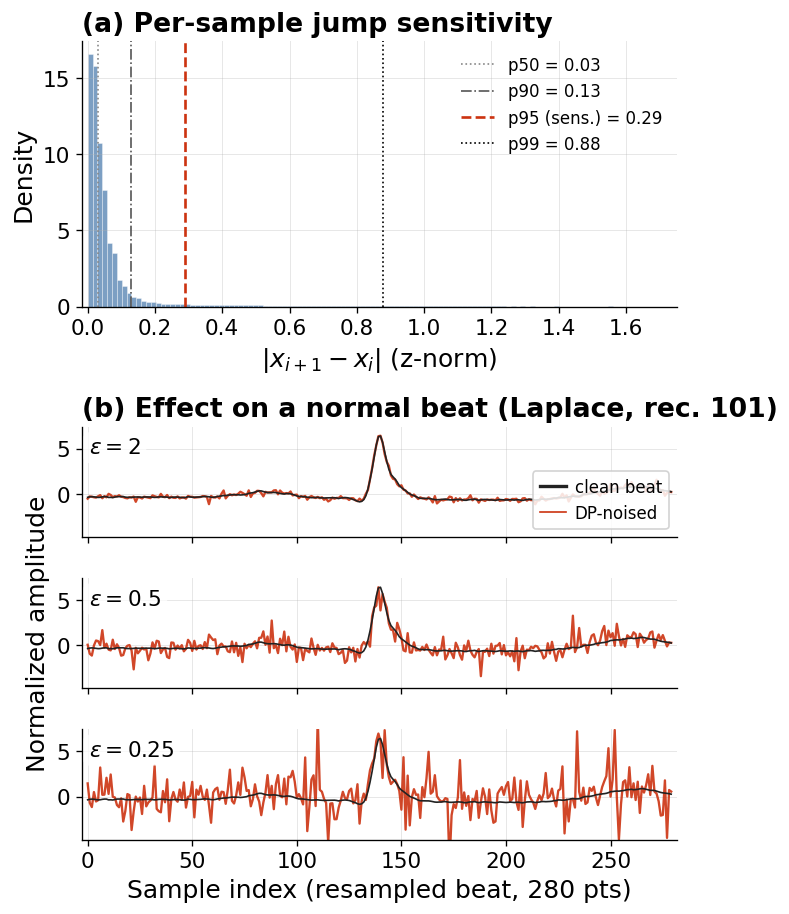

In [2]:
# Fig 1: (a) per-sample jump distribution, (b) one beat under Laplace noise.
# Needs the MIT-BIH signal; runs where the data pipeline is available.
from src.data import load_mitbih_record, preprocess_signal
from configs import DP, SEQ2SEQ

BEAT_LEN, DELTA = SEQ2SEQ.beat_length, DP.sensitivity
EPSILONS, RECORD = [2.0, 0.5, 0.25], "101"
CLEAN_C, NOISE_C = "#222222", "#CC3311"
rng = np.random.default_rng(2026)

# --- jump distribution pooled over DS1+DS2 ---
recs = list(SEQ2SEQ.ds1_records) + list(SEQ2SEQ.ds2_records)
dxs = []
for rid in recs:
    try:
        rec = load_mitbih_record(rid, allow_remote=True)
    except Exception:
        continue
    z = preprocess_signal(rec.signal).astype(np.float64)
    dxs.append(np.abs(np.diff(z)))
dx_pool = np.concatenate(dxs)
p50, p90, p95, p99 = np.percentile(dx_pool, [50, 90, 95, 99])

# --- a clean beat + noised versions ---
def clean_beat(rec_id, n):
    rec = load_mitbih_record(rec_id, allow_remote=True)
    z = preprocess_signal(rec.signal).astype(np.float64)
    mid = len(z)//2; seg = z[mid:mid+int(rec.fs)*10]; r = mid+int(np.argmax(seg))
    half = int(0.35*rec.fs); lo, hi = max(0, r-half), min(len(z), r+half)
    b = np.interp(np.linspace(0,1,n), np.linspace(0,1,hi-lo), z[lo:hi])
    return (b-b.mean())/(b.std()+1e-12)
clean = clean_beat(RECORD, BEAT_LEN); xb = np.arange(BEAT_LEN)
noisy = {e: clean + rng.laplace(0.0, DELTA/e, clean.shape) for e in EPSILONS}
allv = np.concatenate([clean]+list(noisy.values()))
ylo, yhi = np.percentile(allv, 0.5), np.percentile(allv, 99.5)
pad = 0.1*(yhi-ylo); ylo, yhi = ylo-pad, yhi+pad

fig = plt.figure(figsize=(STYLE["col_w"], STYLE["col_w"]*1.35))
gs = GridSpec(5, 1, figure=fig, height_ratios=[2.4, 0.35, 1, 1, 1], hspace=0.32)
axH = fig.add_subplot(gs[0, 0])
arr = dx_pool[dx_pool <= np.percentile(dx_pool, 99.9)]
axH.hist(arr, bins=120, color="#4477AA", alpha=0.7, edgecolor="white", linewidth=0.3, density=True)
for val, c, ls, lbl in [(p50,"#888888",":",f"p50 = {p50:.2f}"),
                        (p90,"#555555","-.",f"p90 = {p90:.2f}"),
                        (p95,"#CC3311","--",f"p95 (sens.) = {p95:.2f}"),
                        (p99,"#000000",":",f"p99 = {p99:.2f}")]:
    axH.axvline(val, color=c, linestyle=ls, linewidth=1.6 if "sens" in lbl else 1.0, label=lbl)
axH.set_xlabel(r"$|x_{i+1}-x_i|$ (z-norm)"); axH.set_ylabel("Density")
axH.set_title("(a) Per-sample jump sensitivity", fontweight="bold", loc="left")
axH.legend(frameon=False); axH.margins(x=0.01)
axes = [fig.add_subplot(gs[i+2, 0]) for i in range(3)]
for i, (ax, e) in enumerate(zip(axes, EPSILONS)):
    ax.plot(xb, clean, color=CLEAN_C, lw=1.0, zorder=3)
    ax.plot(xb, noisy[e], color=NOISE_C, lw=1.4, alpha=0.9, zorder=2)
    ax.set_ylim(ylo, yhi); ax.margins(x=0.01)
    ax.text(0.012, 0.90, fr"$\varepsilon = {e:g}$", transform=ax.transAxes, ha="left", va="top",
            fontsize=STYLE["annot"], fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
    if i == 0:
        ax.legend(handles=[Line2D([],[],color=CLEAN_C,lw=2,label="clean beat"),
                           Line2D([],[],color=NOISE_C,lw=1,label="DP-noised")],
                  loc="lower right", frameon=True, framealpha=0.85, handlelength=1.6,
                  handletextpad=0.5, borderaxespad=0.5)
        ax.set_title(f"(b) Effect on a normal beat (Laplace, rec. {RECORD})", fontweight="bold", loc="left")
    if i < 2:
        ax.set_xticklabels([])
axes[-1].set_xlabel("Sample index (resampled beat, 280 pts)")
axes[1].set_ylabel("Normalized amplitude")
fig.tight_layout()
save(fig, "figure1_sensitivity_and_beat_vertical"); plt.show()


## Figure 2 — utility vs ε: seq2seq (solid) + Random Forest (dashed)

saved <repo>/results/figures/utility_vs_epsilon_rf.png


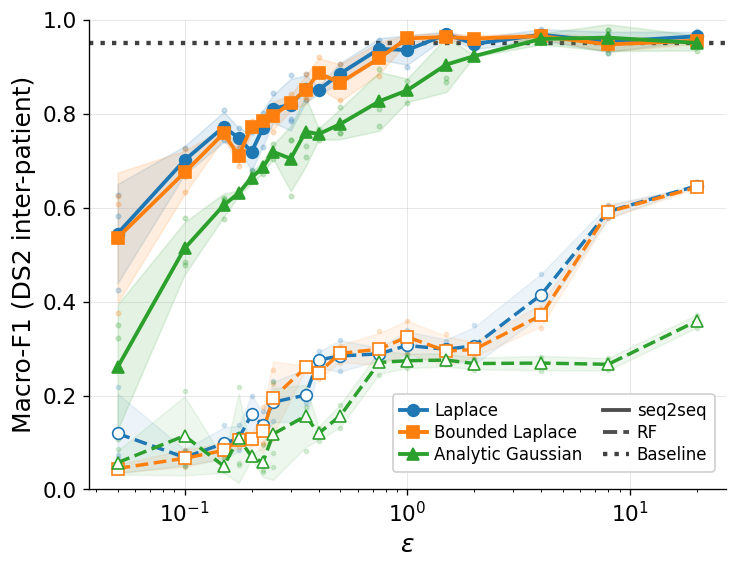

In [3]:
su = pd.read_csv(RESULTS/"second_utility_summary.csv")
EPS_RE = re.compile(r"eps_([0-9.eE+-]+)_delta_([0-9.eE+-]+)")
def seed_points(root, mech):
    out = {}; md_ = root/mech
    if not md_.is_dir(): return out
    for run in sorted(md_.iterdir()):
        m = EPS_RE.match(run.name)
        if not m: continue
        for sd in run.glob("seed_*"):
            mp = sd/"metrics.pkl"
            if mp.exists():
                try: out.setdefault(float(m.group(1)), []).append(pickle.load(open(mp,"rb"))["macro_f1"])
                except Exception: pass
    return out

fig, ax = plt.subplots(figsize=(STYLE["col_w"], STYLE["col_w"]*0.78))
for mech in MECH_ORDER:
    c = MECH_COLORS[mech]
    seq = su[(su.model=="seq2seq")&(su.mechanism==mech)].sort_values("eps")
    rf  = su[(su.model=="random_forest")&(su.mechanism==mech)].sort_values("eps")
    ax.plot(seq.eps, seq.macro_f1, "-", color=c, marker=MECH_MARKERS[mech], zorder=3)
    ax.fill_between(seq.eps, seq.macro_f1-seq.macro_f1_std, seq.macro_f1+seq.macro_f1_std, color=c, alpha=0.13)
    for e,v in seed_points(RESULTS/"dp", mech).items():
        ax.scatter([e]*len(v), v, s=7, color=c, alpha=0.22, zorder=2)
    ax.plot(rf.eps, rf.macro_f1, "--", color=c, marker=MECH_MARKERS[mech], lw=STYLE["linewidth"]*0.9,
            markerfacecolor="white", zorder=3)
    ax.fill_between(rf.eps, rf.macro_f1-rf.macro_f1_std, rf.macro_f1+rf.macro_f1_std, color=c, alpha=0.08)
    for e,v in seed_points(RESULTS/"utility_rf", mech).items():
        ax.scatter([e]*len(v), v, s=6, color=c, alpha=0.16, zorder=2)
ax.axhline(0.95, color="0.25", ls=":", lw=2.6, zorder=0)
ax.set_xscale("log"); ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel("Macro-F1 (DS2 inter-patient)")
ax.set_ylim(0, 1.0)
mech_h = [Line2D([],[],color=MECH_COLORS[m],marker=MECH_MARKERS[m],lw=STYLE["linewidth"],label=MECH_LABELS[m]) for m in MECH_ORDER]
style_h = [Line2D([],[],color="0.3",ls="-",label="seq2seq"),
           Line2D([],[],color="0.3",ls="--",label="RF"),
           Line2D([],[],color="0.25",ls=":",lw=2.6,label="Baseline")]
# One framed legend block in the empty central-right gap (above RF, below the
# seq2seq plateau) so no curve is touched.
#ax.legend(handles=mech_h + style_h, loc="center", bbox_to_anchor=(0.9, 0.17), ncol=1,
ax.legend(handles=mech_h + style_h, loc="center", bbox_to_anchor=(0.73, 0.12), ncol=2,
          frameon=True, framealpha=0.93, fontsize=10.0, handlelength=1.6,
          handletextpad=0.45, labelspacing=0.25, borderpad=0.45,
          columnspacing=1.2)
fig.tight_layout(); save(fig, "utility_vs_epsilon_rf"); plt.show()


## Figure 3 — per-class utility vs ε (colour = class, line style = mechanism)

saved <repo>/results/figures/per_class_vs_epsilon_combined.png


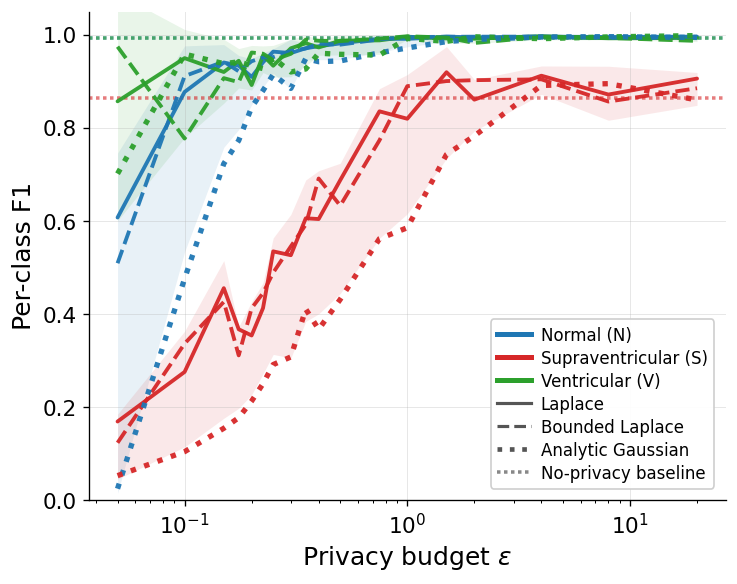

In [4]:
fig, ax = plt.subplots(figsize=(STYLE["col_w"], STYLE["col_w"]*0.80))
for cls in ["N","S","V"]:
    g = util_sweep.groupby("eps")[f"f1_{cls}"].agg(["mean","std"]).reset_index()
    ax.fill_between(g["eps"], g["mean"]-g["std"], g["mean"]+g["std"],
                    color=CLASS_COLORS[cls], alpha=0.10, linewidth=0, zorder=1)
for mech in MECH_ORDER:
    sub = util_sweep[util_sweep["mechanism"]==mech].sort_values("eps")
    if sub.empty: continue
    for cls in ["N","S","V"]:
        grp = sub.groupby("eps")[f"f1_{cls}"].mean().reset_index()
        ax.plot(grp["eps"], grp[f"f1_{cls}"], linestyle=MECH_LS[mech], color=CLASS_COLORS[cls],
                linewidth=(3.2 if mech=="gaussian_analytic" else STYLE["linewidth"]),
                alpha=0.95, solid_capstyle="round", zorder=3)
for cls in ["N","S","V"]:
    if cls in baseline_per_class:
        ax.axhline(baseline_per_class[cls], color=CLASS_COLORS[cls], linestyle=(0,(1,1)),
                   linewidth=2.1, alpha=0.6, zorder=2)
ax.set_xscale("log"); ax.set_ylim(0, 1.05)
ax.set_xlabel(r"Privacy budget $\varepsilon$"); ax.set_ylabel("Per-class F1")
class_h = [Line2D([0],[0],color=CLASS_COLORS[c],lw=3,label=CLASS_FULL[c]) for c in ["N","S","V"]]
mech_h  = [Line2D([0],[0],color="#555",linestyle=MECH_LS[m],lw=(2.8 if m=="gaussian_analytic" else 1.9),label=MECH_LABELS[m]) for m in MECH_ORDER]
extra_h = [Line2D([0],[0],color="#888",linestyle=(0,(1,1)),lw=2.1,label="No-privacy baseline")]
ax.legend(handles=class_h+mech_h+extra_h, loc="lower right", ncol=1, frameon=True,
          framealpha=0.95, handlelength=2.0, labelspacing=0.3, handletextpad=0.6,
          borderaxespad=0.7)
fig.tight_layout(); save(fig, "per_class_vs_epsilon_combined"); plt.show()


## Figure 4 — privacy-utility map with attacker band (full width)

saved <repo>/results/figures/money_figure_attacker_band.png


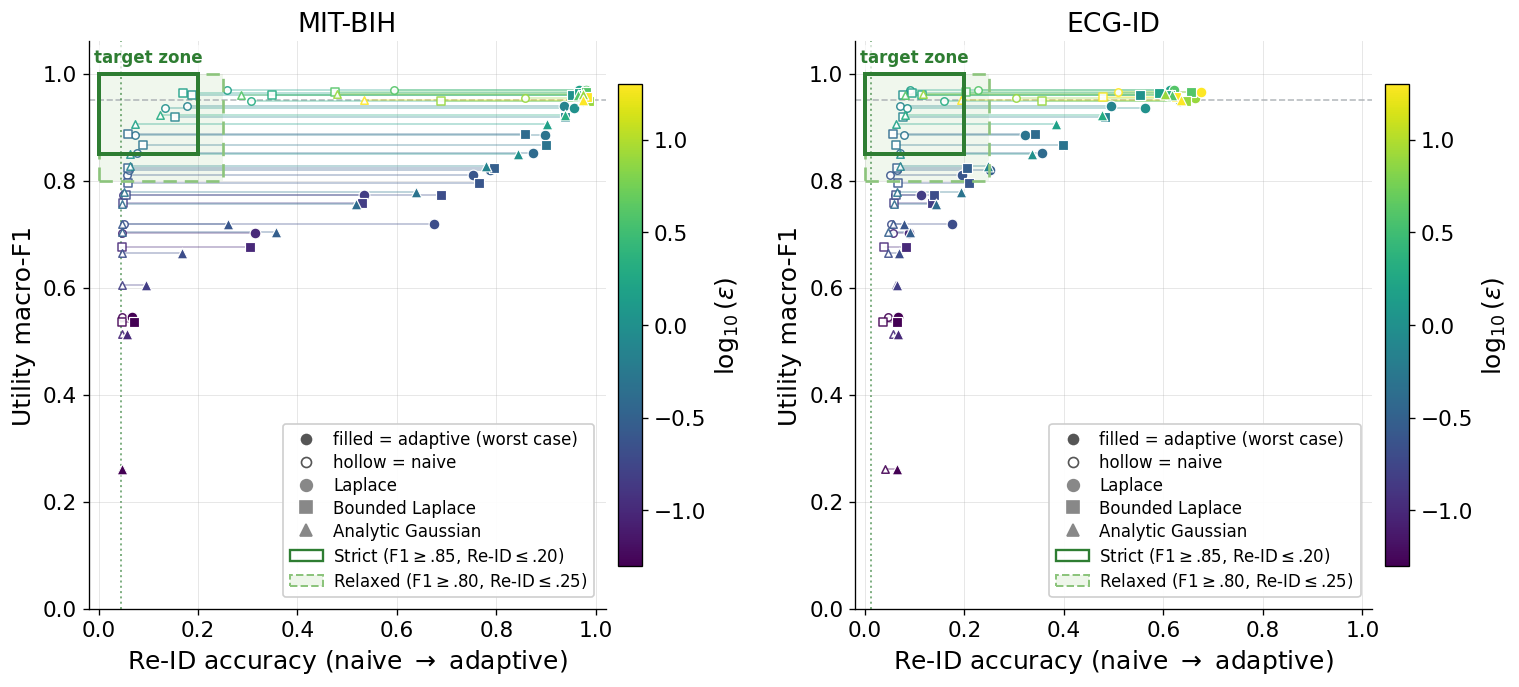

In [5]:
STRICT  = {"util":0.85, "reid":0.20}
RELAXED = {"util":0.80, "reid":0.25}
def build_segments(reid_agg, util_agg_in):
    if reid_agg is None or reid_agg.empty: return pd.DataFrame()
    naive = (reid_agg[reid_agg.threat_model=="clean_attacker"][["mechanism","eps","delta","reid_mean","reid_std"]]
             .rename(columns={"reid_mean":"naive_mean","reid_std":"naive_std"}))
    adapt = (reid_agg[reid_agg.threat_model=="adaptive_attacker"][["mechanism","eps","delta","reid_mean","reid_std"]]
             .rename(columns={"reid_mean":"adapt_mean","reid_std":"adapt_std"}))
    return naive.merge(adapt, on=["mechanism","eps","delta"]).merge(util_agg_in, on=["mechanism","eps","delta"])
def draw_zones(ax):
    TOP = 1.0  # utility ceiling -> closed rectangles with a visible top edge
    ax.add_patch(Rectangle((0,RELAXED["util"]), RELAXED["reid"], TOP-RELAXED["util"],
                 facecolor="#eef6ea", alpha=0.85, edgecolor="none", zorder=0))
    ax.add_patch(Rectangle((0,RELAXED["util"]), RELAXED["reid"], TOP-RELAXED["util"],
                 facecolor="none", edgecolor="#8cc47c", linestyle=(0,(5,3)), linewidth=1.6, zorder=4.5))
    ax.add_patch(Rectangle((0,STRICT["util"]), STRICT["reid"], TOP-STRICT["util"],
                 facecolor="none", edgecolor="#2e7d32", linewidth=2.4, zorder=5))
    ax.text(STRICT["reid"]/2, TOP+0.03, "target zone", color="#2e7d32", fontsize=STYLE["legend"],
            fontweight="bold", ha="center", va="center", zorder=6,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7))

seg_mit = build_segments(reid_mit_agg, util_agg); seg_ecg = build_segments(reid_ecg_agg, util_agg)
fig, axes = plt.subplots(1, 2, figsize=(STYLE["full_w"], STYLE["full_w"]*0.46))
for ax, seg, lab, rand in zip(axes, [seg_mit, seg_ecg], ["MIT-BIH","ECG-ID"], [reid_mit_random, reid_ecg_random]):
    if seg.empty:
        ax.set_title(f"{lab} (no naive-attacker data)"); continue
    eps_vals = sorted(seg["eps"].unique()); norm = plt.Normalize(np.log10(min(eps_vals)), np.log10(max(eps_vals)))
    cmap = plt.cm.viridis; draw_zones(ax)
    for mech in MECH_ORDER:
        for _, row in seg[seg.mechanism==mech].iterrows():
            col = cmap(norm(np.log10(row["eps"])))
            ax.plot([row.naive_mean, row.adapt_mean], [row.util_mean]*2, color=col, lw=0.9, alpha=0.4,
                    solid_capstyle="round", zorder=2)
            ax.errorbar(row.adapt_mean, row.util_mean,
                        xerr=(row.adapt_std if pd.notna(row.adapt_std) else 0.0),
                        yerr=(row.util_std if pd.notna(row.util_std) else 0.0),
                        fmt="none", ecolor=col, elinewidth=0.7, capsize=1.2,
                        alpha=0.5, zorder=3.5)
            ax.scatter(row.adapt_mean, row.util_mean, marker=MECH_MARKERS[mech], color=col,
                       s=42, edgecolor="white", linewidth=0.7, zorder=4)
            ax.scatter(row.naive_mean, row.util_mean, marker=MECH_MARKERS[mech], facecolor="white",
                       edgecolor=col, s=20, linewidth=0.9, alpha=0.9, zorder=3)
    if not np.isnan(util_baseline_macro):
        ax.axhline(util_baseline_macro, color="#9aa0a6", ls="--", lw=1.0, alpha=0.7, zorder=1)
    if not np.isnan(rand):
        ax.axvline(rand, color="#2e7d32", ls=":", lw=1.2, alpha=0.6, zorder=1)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, ax=ax, label=r"$\log_{10}(\varepsilon)$", shrink=0.85, pad=0.02)
    ax.set_xlabel(r"Re-ID accuracy (naive $\rightarrow$ adaptive)"); ax.set_ylabel("Utility macro-F1")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(0, 1.06); ax.set_title(f"{lab}")
fill_h = [Line2D([0],[0],marker="o",color="none",mfc="#555",mec="white",ms=8,label="filled = adaptive"),
          Line2D([0],[0],marker="o",color="none",mfc="white",mec="#555",ms=6,label="hollow = naive")]
mech_h = [Line2D([0],[0],marker=MECH_MARKERS[m],color="none",mfc="#888",mec="#888",ms=7,label=MECH_LABELS[m]) for m in MECH_ORDER]
zone_h = [Patch(facecolor="none",edgecolor="#2e7d32",lw=1.4,label=r"Strict (F1$\geq$.85, Re-ID$\leq$.20)"),
          Patch(facecolor="#eef6ea",edgecolor="#8cc47c",ls="--",lw=1.2,label=r"Relaxed (F1$\geq$.80, Re-ID$\leq$.25)")]
for _ax in axes:
    _ax.legend(handles=fill_h+mech_h+zone_h, loc="lower right", ncol=1, frameon=True,
               framealpha=0.95, labelspacing=0.3, handletextpad=0.6, borderaxespad=0.7)
fig.tight_layout()
save(fig, "money_figure_attacker_band"); plt.show()


## Figure 5 — re-ID vs ε: adaptive (solid) + temporally-aware (dashed)

saved <repo>/results/figures/reid_robustness_temporal.png


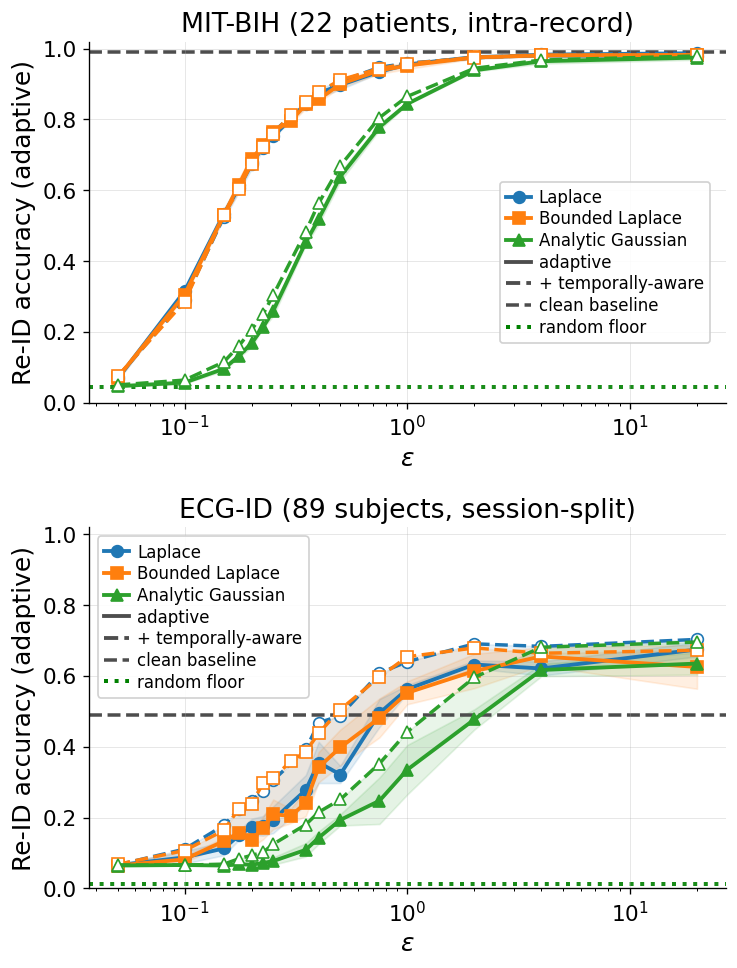

In [6]:
dn = pd.read_csv(RESULTS/"denoise_attacker_summary.csv")
panels = [("mitbih","MIT-BIH (22 patients, intra-record)", 0.99, reid_mit_random),
          ("ecgid","ECG-ID (89 subjects, session-split)", 0.49, reid_ecg_random)]
fig, axes = plt.subplots(2, 1, figsize=(STYLE["col_w"], STYLE["col_w"]*1.3))
for ax, (db, title, clean, rand) in zip(axes, panels):
    d = dn[dn.database==db]
    for mech in MECH_ORDER:
        s = d[d.mechanism==mech].sort_values("eps")
        if s.empty: continue
        c = MECH_COLORS[mech]
        ax.plot(s.eps, s.adapt_mean, "-", color=c, marker=MECH_MARKERS[mech], zorder=3)
        ax.fill_between(s.eps, s.adapt_mean-s.adapt_std, s.adapt_mean+s.adapt_std, color=c, alpha=0.12)
        ax.plot(s.eps, s.dn_mean, "--", color=c, marker=MECH_MARKERS[mech], lw=STYLE["linewidth"]*0.9,
                markerfacecolor="white", zorder=3)
        if db == "ecgid":
            ax.fill_between(s.eps, s.adapt_mean, s.dn_mean, color=c, alpha=0.10)
    ax.axhline(clean, color="0.3", ls="--", lw=2.1, zorder=1)
    if not np.isnan(rand): ax.axhline(rand, color="green", ls=":", lw=2.4, alpha=0.9, zorder=1)
    ax.set_xscale("log"); ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel("Re-ID accuracy (adaptive)")
    ax.set_ylim(0, 1.02); ax.set_title(title)
h = [Line2D([],[],color=MECH_COLORS[m],marker=MECH_MARKERS[m],lw=STYLE["linewidth"],label=MECH_LABELS[m]) for m in MECH_ORDER]
h += [Line2D([],[],color="0.3",ls="-",label="adaptive"),
      Line2D([],[],color="0.3",ls="--",label="+ temporally-aware"),
      Line2D([],[],color="0.3",ls="--",lw=2.1,label="clean baseline"),
      Line2D([],[],color="green",ls=":",lw=2.4,label="random floor")]
leg_cfg = [("lower right", (0.99, 0.14)), ("upper left", None)]  # lift MIT-BIH off the random floor
for _ax, (_loc, _bb) in zip(axes, leg_cfg):
    kw = dict(handles=h, loc=_loc, ncol=1, frameon=True, framealpha=0.9,
              fontsize=STYLE["legend"], labelspacing=0.22, handlelength=1.5,
              handletextpad=0.45, borderaxespad=0.55)
    if _bb is not None:
        kw["bbox_to_anchor"] = _bb
    _ax.legend(**kw)
fig.tight_layout()
save(fig, "reid_robustness_temporal"); plt.show()
